# Calibration — TAUSO vs OligoAI

Only TAUSO and OligoAI predict calibrated %inhibition; the rankers (PFRED/OligoWalk/sfold/
miRanda) are excluded here — absolute error is not their goal.

In [1]:
import _viz as v
v.setup_style()
import numpy as np, pandas as pd, matplotlib.pyplot as plt
R = v.load_results()
summary, preds = R['summary'], v.add_cohort_mean(R['preds'])
breakdown = R['breakdown']
print('test oligos:', len(preds), '| patent cohorts:', preds.custom_id.nunique(), '| scorers:', summary.scorer.nunique())

test oligos: 20846 | patent cohorts: 269 | scorers: 11


## Reliability — predicted vs observed inhibition

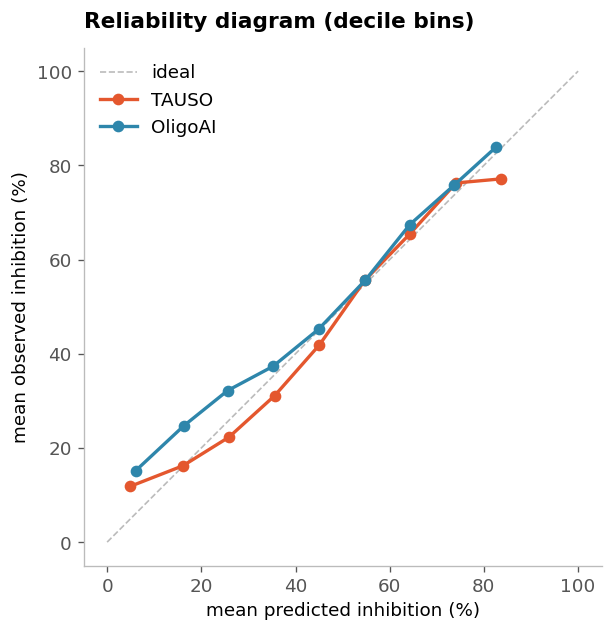

In [2]:
fig, ax = plt.subplots(figsize=(5.6, 5.4))
ax.plot([0,100],[0,100], color='#bbb', ls='--', lw=1, label='ideal')
for s in ['TAUSO','oligo_ai_score']:
    r = v.reliability(preds, s)
    ax.plot(r.pred, r.obs, marker='o', color=v.color(s), lw=2, label=v.disp(s))
ax.set_xlabel('mean predicted inhibition (%)'); ax.set_ylabel('mean observed inhibition (%)')
ax.set_title('Reliability diagram (decile bins)'); ax.legend(frameon=False); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

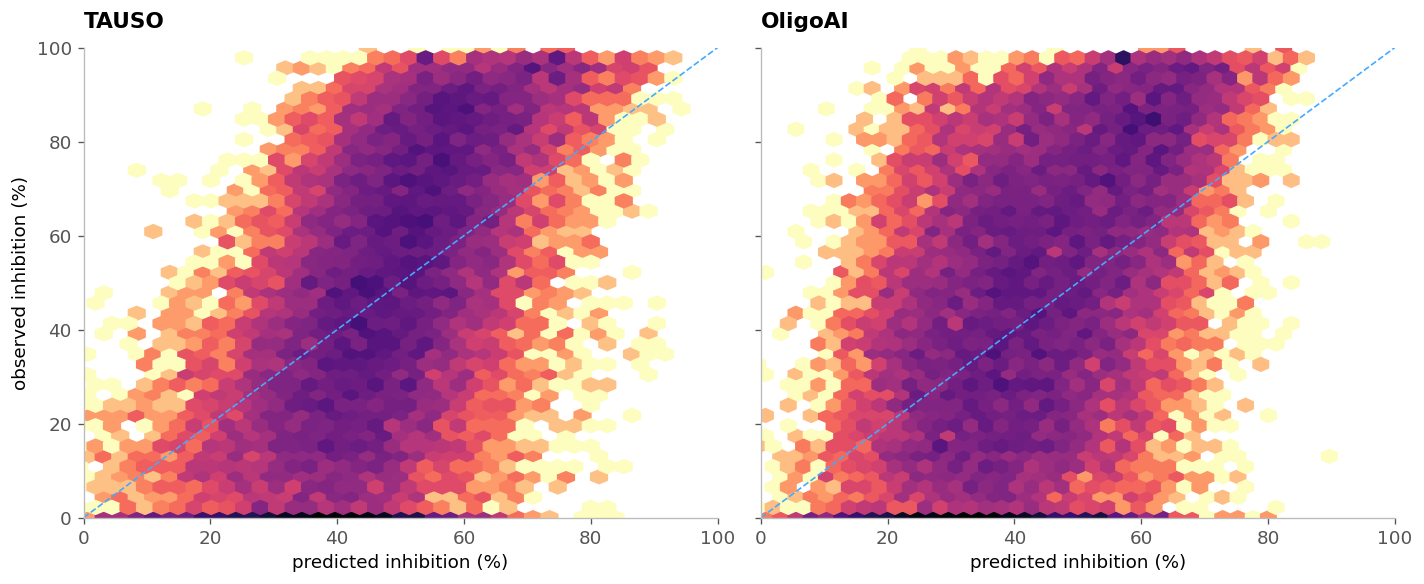

In [3]:
# predicted vs observed density
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for a, s in zip(ax, ['TAUSO','oligo_ai_score']):
    hb = a.hexbin(preds[s], preds['Inhibition(%)'], gridsize=40, cmap='magma_r', mincnt=1, bins='log')
    a.plot([0,100],[0,100], color='#4af', ls='--', lw=1)
    a.set_title(v.disp(s)); a.set_xlabel('predicted inhibition (%)'); a.set_xlim(0,100); a.set_ylim(0,100)
ax[0].set_ylabel('observed inhibition (%)'); plt.tight_layout(); plt.show()

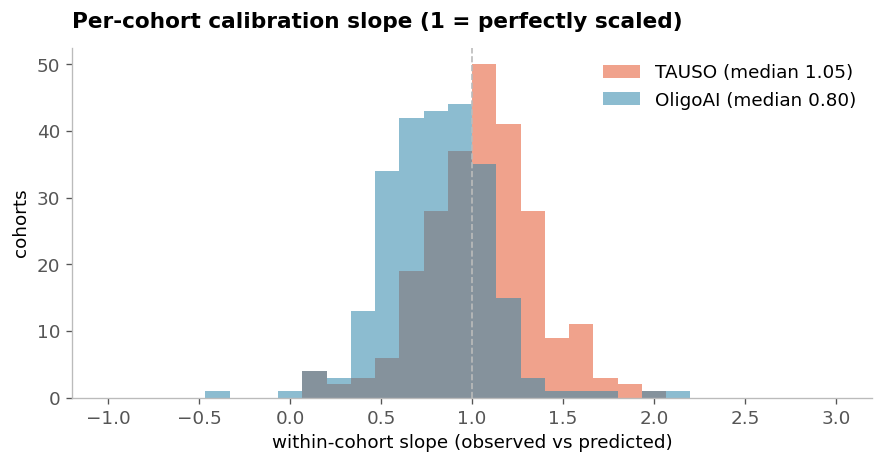

In [4]:
# per-cohort calibration slope: regress observed ~ predicted within each patent cohort
def slopes(scorer):
    out=[]
    for _, sub in preds.groupby('custom_id'):
        y=sub['Inhibition(%)'].to_numpy(); x=sub[scorer].to_numpy()
        if len(y)>=8 and np.ptp(x)>0: out.append(np.polyfit(x, y, 1)[0])
    return np.array(out)
fig, ax = plt.subplots(figsize=(7.5, 4))
for s in ['TAUSO','oligo_ai_score']:
    sl=slopes(s); ax.hist(sl, bins=30, range=(-1,3), color=v.color(s), alpha=.55, label=f'{v.disp(s)} (median {np.median(sl):.2f})')
ax.axvline(1, color='#bbb', ls='--', lw=1); ax.set_xlabel('within-cohort slope (observed vs predicted)'); ax.set_ylabel('cohorts')
ax.set_title('Per-cohort calibration slope (1 = perfectly scaled)'); ax.legend(frameon=False); plt.tight_layout(); plt.show()

In [5]:
# global calibration metrics
g = summary[summary.grouping=='GLOBAL'].set_index('scorer').loc[['TAUSO','oligo_ai_score'], ['global_spearman','MAE','RMSE']]
g.index = [v.disp(s) for s in g.index]; g.round(2)

,global_spearman,MAE,RMSE
TAUSO,0.55,20.26,24.50
OligoAI,0.46,21.67,26.08
